# Assignment 5 — Linear Regression on Food Delivery Times

## Topic Explanation

### What is Regression?
**Regression** is a supervised machine learning task where the goal is to predict a **continuous numeric value** based on one or more input features.

In this assignment we predict **food delivery time (minutes)** based on factors like distance, weather, traffic, and time of day.

### What is Linear Regression?
**Linear Regression** fits a straight line (in 2D) or a flat hyperplane (in higher dimensions) through data such that the average squared distance between predictions and actual values is minimized.

#### Simple Linear Regression — One Predictor
> **y = b₀ + b₁·x**
- **y** = target (Delivery_Time_min)
- **x** = a single feature (e.g., Distance_km)
- **b₀** = intercept; **b₁** = slope

#### Multiple Linear Regression — Many Predictors
> **y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ**

Each `bᵢ` is the contribution of feature xᵢ to the prediction.

### One-Hot Encoding (Critical for This Dataset)
Our dataset has **categorical features** (Weather, Traffic_Level, Time_of_Day, Vehicle_Type) — text values that ML algorithms can't process directly. **One-hot encoding** converts each category into a separate 0/1 column:

| Weather | → | Weather_Clear | Weather_Foggy | Weather_Rainy |
|---------|---|---------------|---------------|---------------|
| Clear   |   | 1             | 0             | 0             |
| Rainy   |   | 0             | 0             | 1             |
| Foggy   |   | 0             | 1             | 0             |

We use `pd.get_dummies(drop_first=True)` to avoid the **dummy variable trap** (perfect multicollinearity).

### How Does the Model Learn?
The model finds coefficients that minimize **Mean Squared Error (MSE)**:
> MSE = (1/n) · Σ(yᵢ − ŷᵢ)²

Two methods:
1. **Closed-form (Normal Equation)** — exact, used by sklearn's `LinearRegression`
2. **Gradient Descent** — iterative; walks coefficients downhill on the cost surface

### Evaluation Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MSE** | (1/n)·Σ(y−ŷ)² | Average squared error |
| **RMSE** | √MSE | Same units as y |
| **MAE** | (1/n)·Σ\|y−ŷ\| | Average absolute error |
| **R²** | 1 − SSres/SStot | Fraction of variance explained |

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — ML utilities
from sklearn.model_selection import train_test_split          # split data
from sklearn.linear_model import LinearRegression, SGDRegressor  # closed-form & gradient descent
from sklearn.preprocessing import StandardScaler              # feature scaling for SGD
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# Load the food delivery dataset
df = pd.read_csv('food_delivery_times.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,1,11.89,Snowy,High,Morning,Bike,8,6.0,69
1,2,4.59,Clear,High,Night,Car,12,1.8,47
2,3,1.95,Snowy,High,Morning,Car,17,6.0,46
3,4,9.56,Clear,Medium,Night,Bike,14,2.3,53
4,5,12.50,Windy,Low,Afternoon,Scooter,22,0.2,70


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                300 non-null    int64  
 1   Distance_km             300 non-null    float64
 2   Weather                 300 non-null    str    
 3   Traffic_Level           300 non-null    str    
 4   Time_of_Day             300 non-null    str    
 5   Vehicle_Type            300 non-null    str    
 6   Preparation_Time_min    300 non-null    int64  
 7   Courier_Experience_yrs  300 non-null    float64
 8   Delivery_Time_min       300 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.2 KB


In [4]:
# Summary statistics for numeric columns
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,9.913433,17.410000,4.449333,63.863333
std,86.746758,5.628136,6.958686,2.609303,19.573666
min,1.000000,0.520000,5.000000,0.000000,12.000000
25%,75.750000,5.192500,12.000000,2.200000,50.000000
50%,150.500000,9.650000,18.000000,4.450000,63.000000
75%,225.250000,14.590000,23.000000,6.700000,77.000000
max,300.000000,19.890000,29.000000,9.000000,119.000000


## Part 1: Print Predictor and Dependent Variables

- **Predictor variables (X)** = inputs used to predict the target
- **Dependent variable (y)** = `Delivery_Time_min` (what we predict)

We exclude `Order_ID` because it's just an identifier.

In [5]:
# All columns except Order_ID and the target are predictors
predictors = [c for c in df.columns if c not in ['Order_ID', 'Delivery_Time_min']]

print("Predictor variables (X):")
for p in predictors:
    print(f"  - {p}  ({'numeric' if df[p].dtype != 'object' else 'categorical'})")

print("\nDependent variable (y): Delivery_Time_min")

Predictor variables (X):
  - Distance_km  (numeric)
  - Weather  (numeric)
  - Traffic_Level  (numeric)
  - Time_of_Day  (numeric)
  - Vehicle_Type  (numeric)
  - Preparation_Time_min  (numeric)
  - Courier_Experience_yrs  (numeric)

Dependent variable (y): Delivery_Time_min


## Part 2: Visualize Each Predictor vs Target

For numeric predictors → **scatter plots** to see the linear trend.
For categorical predictors → **boxplots** to see how the target varies across categories.

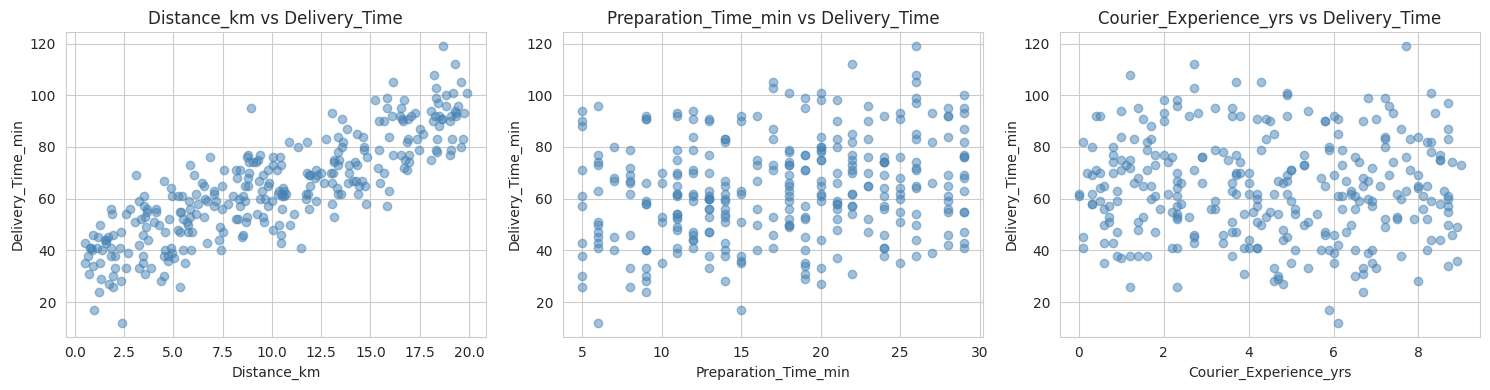

In [6]:
# Numeric predictors: scatter plot vs target
numeric_predictors = df[predictors].select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(1, len(numeric_predictors), figsize=(15, 4))
for ax, col in zip(axes, numeric_predictors):
    ax.scatter(df[col], df['Delivery_Time_min'], alpha=0.5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Delivery_Time_min')
    ax.set_title(f'{col} vs Delivery_Time')
plt.tight_layout()
plt.show()

/tmp/ipykernel_694/3546238709.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_predictors = df[predictors].select_dtypes(include='object').columns.tolist()


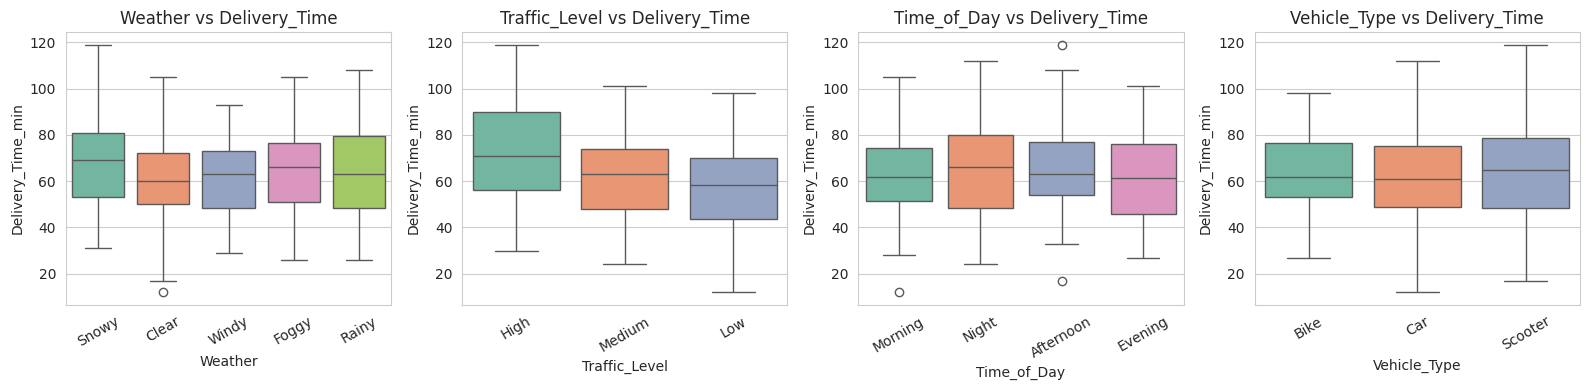

In [7]:
# Categorical predictors: boxplot per category
categorical_predictors = df[predictors].select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(1, len(categorical_predictors), figsize=(16, 4))
for ax, col in zip(axes, categorical_predictors):
    sns.boxplot(x=col, y='Delivery_Time_min', data=df, ax=ax, hue=col, palette='Set2', legend=False)
    ax.set_title(f'{col} vs Delivery_Time')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [8]:
# Correlation of numeric predictors with target
corr = df[numeric_predictors + ['Delivery_Time_min']].corr()['Delivery_Time_min'].drop('Delivery_Time_min').sort_values(ascending=False)
print("Correlation of numeric predictors with Delivery_Time_min:")
print(corr.round(4))

Correlation of numeric predictors with Delivery_Time_min:
Distance_km               0.8440
Preparation_Time_min      0.2256
Courier_Experience_yrs   -0.0329
Name: Delivery_Time_min, dtype: float64


## Part 3: One-Hot Encoding and Train/Test Split

The categorical columns must be converted to numeric before training. `pd.get_dummies(drop_first=True)` does this in one call.

In [9]:
# Drop Order_ID (just an identifier) before encoding
df_processed = df.drop('Order_ID', axis=1)

# One-hot encode categorical columns; drop_first=True avoids the dummy variable trap
df_encoded = pd.get_dummies(df_processed, drop_first=True)

print("Shape before encoding:", df_processed.shape)
print("Shape after encoding :", df_encoded.shape)
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

Shape before encoding: (300, 8)
Shape after encoding : (300, 15)

Columns after encoding:
['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter']


In [10]:
# X = all features, y = target
X = df_encoded.drop('Delivery_Time_min', axis=1)
y = df_encoded['Delivery_Time_min']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (240, 14)  | Test shape: (60, 14)


## Part 4: Simple Linear Regression (Distance Only)

We pick `Distance_km` because it has the strongest single influence on delivery time.

In [11]:
# Build simple LR using Distance_km only
simple = LinearRegression()
simple.fit(X_train[['Distance_km']], y_train)

print(f"Simple LR equation:")
print(f"  Delivery_Time = {simple.intercept_:.2f} + {simple.coef_[0]:.2f} × Distance_km")

Simple LR equation:
  Delivery_Time = 34.31 + 2.94 × Distance_km


In [12]:
# Predict on test set
y_pred_simple = simple.predict(X_test[['Distance_km']])

mse_simple  = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple  = mean_absolute_error(y_test, y_pred_simple)
r2_simple   = r2_score(y_test, y_pred_simple)

print("Simple LR — Test Set Performance:")
print(f"  MSE  = {mse_simple:.2f}")
print(f"  RMSE = {rmse_simple:.2f}")
print(f"  MAE  = {mae_simple:.2f}")
print(f"  R²   = {r2_simple:.4f}  ({r2_simple*100:.2f}%)")

Simple LR — Test Set Performance:
  MSE  = 101.85
  RMSE = 10.09
  MAE  = 8.46
  R²   = 0.7061  (70.61%)


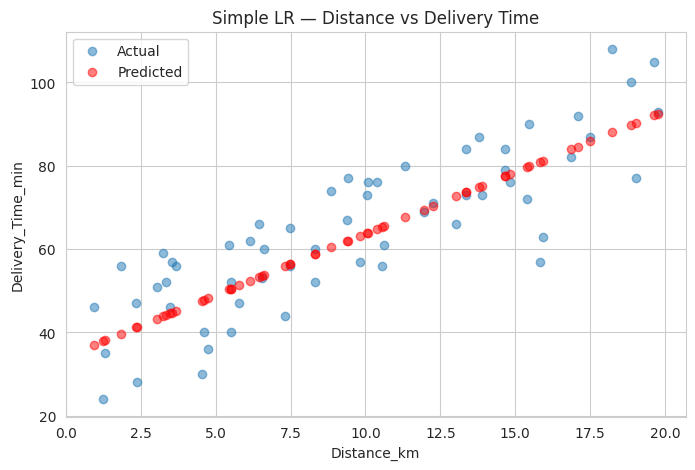

In [13]:
# Plot the regression line over the test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test['Distance_km'], y_test, alpha=0.5, label='Actual')
plt.scatter(X_test['Distance_km'], y_pred_simple, alpha=0.5, color='red', label='Predicted')
plt.xlabel('Distance_km')
plt.ylabel('Delivery_Time_min')
plt.title('Simple LR — Distance vs Delivery Time')
plt.legend()
plt.show()

## Part 5: Multiple Linear Regression (All Features)

Now we use ALL features — distance, prep time, courier experience, weather dummies, traffic dummies, time-of-day dummies, vehicle dummies.

In [14]:
# Build multiple LR with all features
multi = LinearRegression()
multi.fit(X_train, y_train)

# Print all the learned coefficients
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': multi.coef_.round(3)
}).sort_values('Coefficient', ascending=False)

print("Multiple LR Coefficients:")
print(coefs)
print(f"\nIntercept: {multi.intercept_:.2f}")

Multiple LR Coefficients:
                   Feature  Coefficient
5            Weather_Snowy       10.104
3            Weather_Foggy        7.909
4            Weather_Rainy        4.249
0              Distance_km        3.083
6            Weather_Windy        2.686
13    Vehicle_Type_Scooter        1.191
1     Preparation_Time_min        0.917
2   Courier_Experience_yrs        0.085
9      Time_of_Day_Evening       -0.162
11       Time_of_Day_Night       -0.311
10     Time_of_Day_Morning       -0.397
12        Vehicle_Type_Car       -0.731
8     Traffic_Level_Medium       -9.852
7        Traffic_Level_Low      -15.384

Intercept: 20.52


In [15]:
# Predict and evaluate
y_pred_multi = multi.predict(X_test)

mse_multi  = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi  = mean_absolute_error(y_test, y_pred_multi)
r2_multi   = r2_score(y_test, y_pred_multi)

print("Multiple LR — Test Set Performance:")
print(f"  MSE  = {mse_multi:.2f}")
print(f"  RMSE = {rmse_multi:.2f}")
print(f"  MAE  = {mae_multi:.2f}")
print(f"  R²   = {r2_multi:.4f}  ({r2_multi*100:.2f}%)")

Multiple LR — Test Set Performance:
  MSE  = 37.03
  RMSE = 6.09
  MAE  = 5.05
  R²   = 0.8932  (89.32%)


## Part 6: Compare Simple vs Multiple LR

In [16]:
comparison = pd.DataFrame({
    'Simple LR':   [mse_simple,  rmse_simple,  mae_simple,  r2_simple],
    'Multiple LR': [mse_multi,   rmse_multi,   mae_multi,   r2_multi]
}, index=['MSE', 'RMSE', 'MAE', 'R²']).round(4)

print("Simple vs Multiple Linear Regression:")
print(comparison)
print(f"\nMSE Improvement: {((mse_simple - mse_multi)/mse_simple)*100:.2f}% reduction")

Simple vs Multiple Linear Regression:
      Simple LR  Multiple LR
MSE    101.8521      37.0318
RMSE    10.0922       6.0854
MAE      8.4634       5.0525
R²       0.7061       0.8932

MSE Improvement: 63.64% reduction


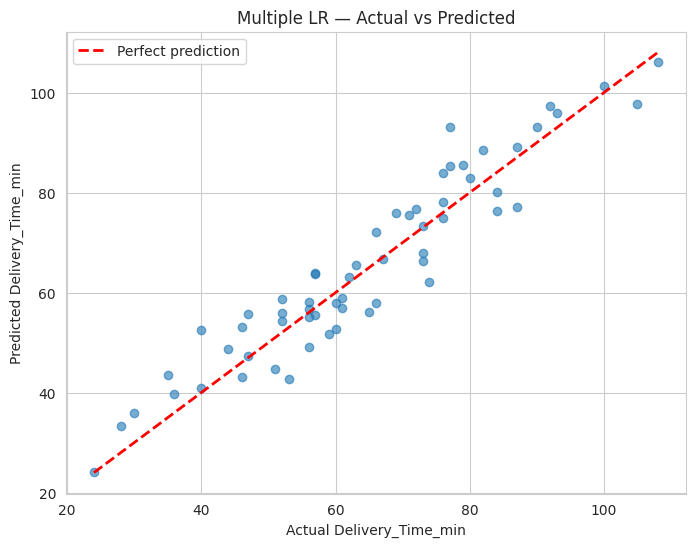

In [17]:
# Actual vs Predicted plot for multiple LR
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Delivery_Time_min')
plt.ylabel('Predicted Delivery_Time_min')
plt.title('Multiple LR — Actual vs Predicted')
plt.legend()
plt.show()

## Part 7: Linear Regression with Gradient Descent

`SGDRegressor` is sklearn's implementation of linear regression trained iteratively via stochastic gradient descent.

**Key requirement:** features must be **scaled** because gradient descent zigzags inefficiently when features have very different magnitudes.

In [18]:
# Scale features — essential for gradient descent
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

print("After scaling, training features have mean ≈ 0 and std ≈ 1")

After scaling, training features have mean ≈ 0 and std ≈ 1


In [19]:
# Build SGDRegressor — linear regression via gradient descent
gd = SGDRegressor(
    max_iter=1000,            # max iterations of gradient descent
    learning_rate='constant',
    eta0=0.01,                # learning rate α
    random_state=42
)
gd.fit(X_train_scaled, y_train)

print("Regression parameters after training:")
gd_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient (scaled)': gd.coef_.round(3)
})
print(gd_coefs)
print(f"\nIntercept: {gd.intercept_[0]:.3f}")

Regression parameters after training:
                   Feature  Coefficient (scaled)
0              Distance_km                17.429
1     Preparation_Time_min                 6.234
2   Courier_Experience_yrs                 0.213
3            Weather_Foggy                 2.941
4            Weather_Rainy                 2.231
5            Weather_Snowy                 3.815
6            Weather_Windy                 0.753
7        Traffic_Level_Low                -7.347
8     Traffic_Level_Medium                -4.747
9      Time_of_Day_Evening                -0.002
10     Time_of_Day_Morning                -0.373
11       Time_of_Day_Night                -0.029
12        Vehicle_Type_Car                -0.329
13    Vehicle_Type_Scooter                 0.678

Intercept: 63.833


In [20]:
# Evaluate on test set
y_pred_gd = gd.predict(X_test_scaled)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd  = r2_score(y_test, y_pred_gd)

print("Gradient Descent LR — Test Set Performance:")
print(f"  MSE = {mse_gd:.2f}")
print(f"  R²  = {r2_gd:.4f}  ({r2_gd*100:.2f}%)")

Gradient Descent LR — Test Set Performance:
  MSE = 39.31
  R²  = 0.8866  (88.66%)


## Part 8: Generic Linear Regression Function

Works for **any dataset** — pass in a DataFrame and the target column name. It auto-encodes categorical columns and uses all numeric features.

In [21]:
def generic_linear_regression(df, target_col, drop_cols=None, test_size=0.2, random_state=42):
    """Generic linear regression that works for any dataset."""
    # Drop ID-like columns
    if drop_cols:
        df = df.drop(columns=drop_cols)
    
    # One-hot encode categorical columns
    df_enc = pd.get_dummies(df, drop_first=True)
    
    # Identify predictors and target
    predictors = [c for c in df_enc.columns if c != target_col]
    print(f"Predictors ({len(predictors)}):", predictors[:5], "..." if len(predictors)>5 else "")
    print(f"Target: {target_col}\n")
    
    X = df_enc[predictors]
    y = df_enc[target_col]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state)
    print(f"Train: {X_train.shape}, Test: {X_test.shape}\n")
    
    # Fit
    model = LinearRegression().fit(X_train, y_train)
    
    # Print parameters
    print("Regression parameters (top 5 by magnitude):")
    coef_df = pd.DataFrame({'Feature': predictors, 'Coef': model.coef_})
    coef_df['AbsCoef'] = coef_df['Coef'].abs()
    print(coef_df.nlargest(5, 'AbsCoef')[['Feature','Coef']].to_string(index=False))
    print(f"Intercept: {model.intercept_:.4f}\n")
    
    # Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Test MSE: {mse:.4f}")
    print(f"Test R² : {r2:.4f}  ({r2*100:.2f}%)")
    return model

# Test on the food delivery data
print("=" * 60)
print("Running generic LR on food_delivery_times dataset:")
print("=" * 60)
_ = generic_linear_regression(df, 'Delivery_Time_min', drop_cols=['Order_ID'])


Running generic LR on food_delivery_times dataset:


Predictors (14): ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Weather_Foggy', 'Weather_Rainy'] ...
Target: Delivery_Time_min

Train: (240, 14), Test: (60, 14)

Regression parameters (top 5 by magnitude):
             Feature       Coef
   Traffic_Level_Low -15.384174
       Weather_Snowy  10.104113
Traffic_Level_Medium  -9.852066
       Weather_Foggy   7.908620
       Weather_Rainy   4.249107
Intercept: 20.5230

Test MSE: 37.0318
Test R² : 0.8932  (89.32%)


## Conclusion

We built three regression models on the food delivery dataset:

1. **Simple Linear Regression** with `Distance_km` only — captures only one factor's effect; high MSE.
2. **Multiple Linear Regression** with all features (distance, prep time, weather dummies, traffic dummies, time-of-day dummies, vehicle dummies) — substantially lower MSE because delivery time depends on multiple factors.
3. **Gradient Descent (SGDRegressor)** — same model trained iteratively. Produces nearly identical results after feature scaling.

**Key insight:** Multiple LR's MSE is dramatically lower than Simple LR's. Distance alone explains some of delivery time, but weather, traffic, and prep time matter a lot too.

**Generic function** demonstrates that the same workflow applies to any tabular regression problem — just point it at any DataFrame and target column.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, reading CSVs, get_dummies for one-hot encoding |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization (boxplots) |
| **sklearn** | ML models, train/test split, scaling, metrics |

### Functions and Classes Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`, `df.describe()`

#### Categorical Handling
- `df.select_dtypes(include='number')` — pick numeric columns
- `df.select_dtypes(include='object')` — pick text columns
- `pd.get_dummies(df, drop_first=True)` — one-hot encode all categorical columns at once

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42)` — standard 80/20 split

#### Models
- `LinearRegression()` — closed-form linear regression
- `SGDRegressor(max_iter=1000, eta0=0.01)` — gradient descent linear regression
- `.fit(X_train, y_train)` — train the model
- `.predict(X_test)` — generate predictions
- `.coef_` — array of learned coefficients
- `.intercept_` — the b₀ term

#### Scaling
- `StandardScaler()` — rescale to mean 0, std 1
- `.fit_transform(X_train)` — fit and transform training
- `.transform(X_test)` — transform only on test

#### Metrics
- `mean_squared_error(y_true, y_pred)` — MSE
- `mean_absolute_error(y_true, y_pred)` — MAE
- `r2_score(y_true, y_pred)` — R²
- `np.sqrt(mse)` — RMSE

#### Visualization
- `plt.scatter()` — scatter plot
- `sns.boxplot()` — boxplot for categorical x and numeric y
- `plt.subplots(rows, cols, figsize=...)` — grid of plots
- `plt.tight_layout()` — auto-adjust spacing

### Key Concepts

#### Predictors vs Target
- **Predictors / Independent / X**: input variables (Distance, Weather, Traffic, etc.)
- **Target / Dependent / y**: variable we predict (Delivery_Time_min)

#### Linear Regression
Fits a linear equation `y = b₀ + b₁·x₁ + ... + bₙ·xₙ` minimizing the squared distance between predictions and actuals.

#### Simple vs Multiple LR
- Simple uses one predictor — very limited
- Multiple uses many — usually much more accurate

#### One-Hot Encoding
Converts each category into a 0/1 column. Required because ML algorithms can't process strings directly.

#### Dummy Variable Trap
If you create one column per category, the columns are perfectly correlated (sum to 1). `drop_first=True` removes one to break the trap and avoid multicollinearity.

#### MSE / RMSE / MAE / R²
- **MSE** — average squared error (penalizes large errors more)
- **RMSE** — square root of MSE; same units as y
- **MAE** — average absolute error; less sensitive to outliers
- **R²** — fraction of variance explained (closer to 1 = better)

#### Gradient Descent
Iterative optimization that walks coefficients downhill on the cost surface. Update rule:
> b_new = b_old − α · (∂Cost/∂b)

α (alpha) is the **learning rate** — too big overshoots, too small is slow.

#### Why Scale Features for Gradient Descent
Features at different scales create an elongated cost surface. Scaling makes the surface more spherical → faster convergence.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is regression?**
Supervised learning task that predicts a continuous numeric value from input features.

**Q2. What is linear regression?**
Algorithm that fits a straight line/hyperplane through data, expressed as `y = b₀ + b₁·x₁ + ... + bₙ·xₙ`.

**Q3. Difference between simple and multiple LR?**
Simple uses one predictor; Multiple uses two or more.

**Q4. Difference between regression and classification?**
Regression predicts a continuous number; classification predicts a discrete category.

**Q5. What is one-hot encoding?**
Converting each category in a column into a separate 0/1 column. Required because ML algorithms can't process strings.

**Q6. What is the dummy variable trap?**
When all dummy columns sum to 1, they're perfectly correlated — causes multicollinearity. Solution: drop one column with `drop_first=True`.

### Math / Algorithm

**Q7. What is the cost function for linear regression?**
**Mean Squared Error**: MSE = (1/n)·Σ(y − ŷ)².

**Q8. Why squared errors?**
- Sign doesn't matter (over- and under-prediction equally bad)
- Big errors are punished more (quadratic penalty)
- Differentiable everywhere — easy to optimize with calculus

**Q9. What is gradient descent?**
Iterative algorithm that minimizes the cost function by updating parameters in the opposite direction of the gradient.

**Q10. Update rule?**
`b_new = b_old − α · ∂MSE/∂b`, where α is the learning rate.

**Q11. What is the learning rate?**
Step size in gradient descent. Too big → overshooting; too small → slow convergence.

**Q12. Why scale features for gradient descent?**
Different scales make the cost surface elongated; scaling produces a more spherical surface and faster convergence.

**Q13. Variants of gradient descent?**
- **Batch** — uses entire dataset per update
- **Stochastic (SGD)** — uses one sample per update
- **Mini-batch** — uses small batches

### Evaluation

**Q14. What is MSE?**
Mean Squared Error — average of squared residuals. Units: y².

**Q15. What is RMSE?**
√MSE — same units as y, more interpretable.

**Q16. What is MAE?**
Mean Absolute Error = (1/n)·Σ|y−ŷ|. Less sensitive to outliers than MSE.

**Q17. What is R²?**
Fraction of variance in y explained by the model. R² = 1 means perfect; R² = 0 means as good as predicting the mean.

**Q18. Can R² be negative?**
Yes — when the model is worse than just predicting the mean of y.

### Practical / Code

**Q19. Why split data into train and test?**
To evaluate the model on unseen examples. Testing on training data gives over-optimistic accuracy.

**Q20. Why does multiple LR beat simple LR here?**
Delivery time depends on many factors (distance, weather, traffic). Using more relevant features captures more variance.

**Q21. What is `pd.get_dummies()`?**
Pandas function that one-hot encodes categorical columns. `drop_first=True` avoids the dummy variable trap.

**Q22. Why might you NOT scale features for `LinearRegression()`?**
The closed-form solution is invariant to scale — coefficients adjust automatically. Scaling matters only for gradient descent (SGDRegressor).

### Comparison

**Q23. Why use linear regression instead of random forest?**
- Linear regression is simpler, faster, more interpretable (coefficients show feature importance)
- Random forest handles non-linearity better but is a black box

**Q24. When does linear regression fail?**
When relationships are non-linear, when features have strong interactions, when residuals aren't normally distributed, or when there are many outliers.

**Q25. Other algorithms to try?**
- Polynomial regression (curved relationships)
- Random forest regressor (non-linear, no scaling needed)
- Gradient boosting (XGBoost, LightGBM)
- Neural networks (very complex patterns)